# Planner-Executor-Replan -- Business-Analyst SQL Root-Cause Analysis

## Problem card

- **User/trigger:** a business analyst asks a broad diagnostic question: "Why did total
  revenue drop last week compared to the week before?"
- **Inputs:** the question, plus a real (synthetic) SQLite `sales` table the agent can
  query -- no hand-fed hint about where the drop actually came from.
- **Output:** a root-cause report -- which region, which product, and the specific
  mechanism (a stockout, not a demand or pricing problem) -- with every claim traceable
  to a real SQL query result.
- **Success criteria:** each drill-down query is only run because the previous query's
  real result pointed there (never a fixed, pre-scripted sequence of queries); the final
  root cause is the one the data actually supports, not a plausible-sounding guess.
- **Topology:** **planner-executor-replan**, the same shape as
  `planner_executor_trip_itinerary.ipynb`, applied to data analysis instead of travel:
  a `planner` drafts an initial drill-down plan, each step is a real SQL query executed
  by a deterministic `sql_runner`, an LLM `analyst_agent` turns the result set into a
  plain-English finding, and an LLM `replanner` decides whether the investigation is
  done or a new, previously-unplanned drill-down step is now justified by what the data
  showed.

## Why planner-executor-replan (not a fixed query pipeline)

Root-cause analysis is the textbook case for this pattern: **you cannot write the full
list of queries in advance**, because which query to run next depends entirely on what
the previous one found. "Revenue dropped -- check by region" only makes sense to run
*after* you know revenue actually dropped; "check by product within the worst region"
only makes sense *after* you know which region is worst. A fixed pipeline would have to
either run every possible drill-down query regardless of relevance (wasteful, and
confusing when most turn up nothing) or hardcode one specific investigation path (wrong
the moment the real anomaly lives somewhere else).

## The synthetic dataset (a real, injected root cause)

A local SQLite `sales` table with two weeks of daily rows across 3 regions x 3 products.
One specific combination -- **region `West`, product `Widget Pro`, during `week2`** --
has a real, injected **stockout**: `units_sold` collapses to near zero on several days
purely because `stockout = 1`, while price and demand elsewhere are normal. This is a
genuine root cause baked into the data, not a scripted answer the agents are told in
advance -- the plan has to actually discover it through real queries.

## The five agents (four LLM agents + one deterministic tool step)

| # | Agent/step | Kind | System message role | Reads | Writes |
|---|---|---|---|---|---|
| 1 | `planner` | LLM | Draft the initial ordered drill-down plan from the BA question alone | `question` | `plan` |
| 2 | `sql_runner` | **Deterministic, no LLM** | Actually execute the real SQL query for the current plan step | `plan[step_index]`, prior `findings` | raw query result rows |
| 3 | `analyst_agent` | LLM | Turn one query's raw result rows into a concise, plain-English finding | raw rows | `findings` (append) |
| 4 | `replanner` | LLM | Decide continue / insert a new drill-down step / finish, using only the latest finding | `plan`, `step_index`, latest finding | `plan` (maybe edited), `step_index`, `done` |
| 5 | `report_writer` | LLM | Compile every finding into one root-cause report with a recommendation | all `findings` | `final_report` |

Each LLM agent has its own system message and narrow context, mirroring the trip
notebook: `analyst_agent` only ever sees one query's raw rows, never the plan or other
steps' results; `replanner` only ever sees the plain-English finding, never raw rows or
SQL; `report_writer` only synthesizes what was already found, it never runs a new query
or makes a routing decision.


In [1]:
import os
import sqlite3
import warnings
import logging
from typing import Literal, Optional, TypedDict
from dotenv import load_dotenv, find_dotenv
from pydantic import BaseModel

warnings.filterwarnings("ignore")
logging.getLogger("chromadb").setLevel(logging.ERROR)

load_dotenv(find_dotenv(usecwd=True))
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0.3)

MAX_STEPS = 8

print(f"Model: {OPENAI_MODEL}")


Model: gpt-4o-mini


## Building the synthetic `sales` database

Real SQLite, real rows, one real injected anomaly. `week1` is a normal baseline week
across all region/product combinations; `week2` is identical except `West` /
`Widget Pro` suffers a stockout on 4 of its 7 days (`stockout=1`, `units_sold` crashes,
`revenue` crashes with it) -- everything else in `week2` is normal, ordinary
day-to-day variance.


In [2]:
conn = sqlite3.connect(":memory:")
cur = conn.cursor()
cur.execute('''
    CREATE TABLE sales (
        day INTEGER, week TEXT, region TEXT, product TEXT,
        units_sold INTEGER, unit_price REAL, revenue REAL, stockout INTEGER
    )
''')

import random
random.seed(7)

REGIONS = ["East", "West", "North"]
PRODUCTS = ["Widget Pro", "Widget Lite", "Widget Max"]
BASE_UNITS = {"Widget Pro": 40, "Widget Lite": 60, "Widget Max": 25}
UNIT_PRICE = {"Widget Pro": 45.0, "Widget Lite": 20.0, "Widget Max": 90.0}

rows = []
for week in ["week1", "week2"]:
    for day in range(1, 8):
        for region in REGIONS:
            for product in PRODUCTS:
                base = BASE_UNITS[product]
                units = base + random.randint(-4, 4)
                stockout = 0
                if week == "week2" and region == "West" and product == "Widget Pro" and day in (2, 3, 4, 5):
                    stockout = 1
                    units = random.randint(0, 3)  # real injected stockout collapse
                price = UNIT_PRICE[product]
                revenue = round(units * price, 2)
                rows.append((day, week, region, product, units, price, revenue, stockout))

cur.executemany("INSERT INTO sales VALUES (?,?,?,?,?,?,?,?)", rows)
conn.commit()
print(f"Inserted {len(rows)} rows into sales.")


Inserted 126 rows into sales.


## The BA question (the real input)

Broad and open-ended, exactly how a business analyst would actually ask it -- no hint
about region, product, or mechanism.


In [3]:
ba_question = "Why did total revenue drop last week compared to the week before?"
print(ba_question)


Why did total revenue drop last week compared to the week before?


## Deterministic SQL tools (real queries, no LLM)

Every drill-down level is a real, parameterized SQL query against the actual table --
nothing here is a canned answer.


In [4]:
def q_revenue_by_week() -> list[dict]:
    cur.execute("SELECT week, SUM(revenue) AS total_revenue FROM sales GROUP BY week ORDER BY week")
    cols = [d[0] for d in cur.description]
    return [dict(zip(cols, r)) for r in cur.fetchall()]


def q_revenue_by_region() -> list[dict]:
    cur.execute('''
        SELECT region, week, SUM(revenue) AS total_revenue
        FROM sales GROUP BY region, week ORDER BY region, week
    ''')
    cols = [d[0] for d in cur.description]
    return [dict(zip(cols, r)) for r in cur.fetchall()]


def q_revenue_by_product(region: str) -> list[dict]:
    cur.execute('''
        SELECT product, week, SUM(revenue) AS total_revenue, SUM(units_sold) AS total_units
        FROM sales WHERE region = ? GROUP BY product, week ORDER BY product, week
    ''', (region,))
    cols = [d[0] for d in cur.description]
    return [dict(zip(cols, r)) for r in cur.fetchall()]


def q_stockout_check(region: str, product: str) -> list[dict]:
    cur.execute('''
        SELECT day, week, units_sold, unit_price, revenue, stockout
        FROM sales WHERE region = ? AND product = ? AND week = 'week2' ORDER BY day
    ''', (region, product))
    cols = [d[0] for d in cur.description]
    return [dict(zip(cols, r)) for r in cur.fetchall()]


## State

Structurally identical to the trip notebook's `TripState` -- a mutable `plan`, a
`step_index`, and an accumulating `findings` trail. The `worst_region`/`worst_product`
fields let later steps target the drill-down the data itself pointed at, instead of a
hardcoded region/product.


In [5]:
class RCAState(TypedDict, total=False):
    question: str
    plan: list[str]
    step_index: int
    findings: list[dict]
    raw_results: dict
    worst_region: str
    worst_product: str
    done: bool
    final_report: str


## Agent 1: `planner` -- draft the initial drill-down plan

System message: choose an ordered subset of a fixed query vocabulary. It cannot possibly
know yet which region or product to drill into -- that's the replanner's job, once real
data comes back.


In [6]:
ALLOWED_STEPS = ["revenue_by_week", "revenue_by_region", "revenue_by_product"]

PLANNER_SYSTEM_PROMPT = (
    "You are a data-analysis planning strategist. Given a business analyst's "
    "diagnostic question about a revenue change, choose which investigation steps are "
    "needed and in what order, using ONLY step names from this fixed vocabulary: "
    "revenue_by_week, revenue_by_region, revenue_by_product. Order them from broadest "
    "to narrowest (confirm the overall trend before breaking it down). Do not invent "
    "step names outside this vocabulary, and do not guess which region or product is "
    "responsible -- you have no data yet; that judgment belongs to a later agent once "
    "real query results exist."
)


class RCAPlan(BaseModel):
    steps: list[Literal["revenue_by_week", "revenue_by_region", "revenue_by_product"]]


def planner_node(state: RCAState) -> dict:
    planner_llm = llm.with_structured_output(RCAPlan)
    messages = [
        SystemMessage(content=PLANNER_SYSTEM_PROMPT),
        HumanMessage(content=f"BA question: {state['question']}"),
    ]
    plan = planner_llm.invoke(messages)
    return {"plan": plan.steps, "step_index": 0, "findings": [], "raw_results": {}, "done": False}


## Step 2: `sql_runner` -- deterministic dispatch, real SQL

Looks up the current plan step, runs the corresponding real query, and for
region/product-scoped steps, uses the `worst_region`/`worst_product` the data itself
already identified in an earlier step -- never a hardcoded guess.


In [7]:
def sql_runner_node(state: RCAState) -> dict:
    step = state["plan"][state["step_index"]]
    raw = dict(state.get("raw_results", {}))

    if step == "revenue_by_week":
        result = q_revenue_by_week()
    elif step == "revenue_by_region":
        result = q_revenue_by_region()
    elif step == "revenue_by_product":
        result = q_revenue_by_product(state["worst_region"])
    elif step == "check_stockout":
        result = q_stockout_check(state["worst_region"], state["worst_product"])
    else:
        result = [{"error": f"unknown step {step}"}]

    raw[step] = result
    return {"raw_results": raw}


## Agent 2: `analyst_agent` -- summarize one query's result rows

System message: describe exactly what one result set shows -- and, specifically for the
region/product breakdown steps, name the single worst-performing region or product so
the deterministic code (not the LLM) can wire it into the next query's arguments. This
keeps drill-down targeting grounded in a structured field rather than free text the
replanner would have to re-parse. `analyst_agent_node` below also has a deterministic
fallback that computes `worst_region`/`worst_product` directly from the real query rows
if the LLM's structured extraction misses the field on a given run -- a genuine
robustness gap this notebook hit while building it (the model doesn't always populate
an optional structured-output field even when the data clearly supports it), left in on
purpose so the pipeline degrades gracefully instead of crashing on an occasional LLM
extraction miss.


In [8]:
ANALYST_SYSTEM_PROMPT = (
    "You are a business-data analyst field agent. You will be given the name of one "
    "investigation step and its raw SQL result rows (week1 vs week2 values). Write a "
    "concise 2-3 sentence plain-English summary of what this result shows, focused on "
    "the week-over-week change. State facts and numbers from the data only -- do not "
    "recommend next steps and do not speculate about causes beyond what this specific "
    "result set shows."
)


class AnalystFinding(BaseModel):
    summary: str
    worst_region: Optional[str] = None
    worst_product: Optional[str] = None


def analyst_agent_node(state: RCAState) -> dict:
    step = state["plan"][state["step_index"]]
    raw = state["raw_results"][step]
    analyst_llm = llm.with_structured_output(AnalystFinding)
    messages = [
        SystemMessage(content=ANALYST_SYSTEM_PROMPT),
        HumanMessage(
            content=(
                f"Step: {step}\nRaw result rows: {raw}\n\n"
                "If this result breaks revenue down by region, set worst_region to the "
                "region with the largest week1->week2 revenue decline. If it breaks "
                "revenue down by product, set worst_product to the product with the "
                "largest week1->week2 revenue decline. Otherwise leave both null."
            )
        ),
    ]
    finding = analyst_llm.invoke(messages)
    findings = list(state.get("findings", []))
    findings.append({"step": step, "raw": raw, "summary": finding.summary})
    update = {"findings": findings}

    worst_region = finding.worst_region
    worst_product = finding.worst_product

    # Deterministic fallback: if the LLM's structured extraction missed the
    # worst-performing region/product, compute it directly from the real query
    # rows rather than let a missing field break the pipeline. The LLM's
    # extraction is still what's used when it succeeds -- this only guards
    # against an occasional structured-output miss.
    if step == "revenue_by_region" and not worst_region:
        by_region: dict[str, dict[str, float]] = {}
        for row in raw:
            by_region.setdefault(row["region"], {})[row["week"]] = row["total_revenue"]
        worst_region = min(
            by_region, key=lambda r: by_region[r].get("week2", 0) - by_region[r].get("week1", 0)
        )
    if step == "revenue_by_product" and not worst_product:
        by_product: dict[str, dict[str, float]] = {}
        for row in raw:
            by_product.setdefault(row["product"], {})[row["week"]] = row["total_revenue"]
        worst_product = min(
            by_product, key=lambda p: by_product[p].get("week2", 0) - by_product[p].get("week1", 0)
        )

    if worst_region:
        update["worst_region"] = worst_region
    if worst_product:
        update["worst_product"] = worst_product
    return update


## Agent 3: `replanner` -- continue, insert a step, or finish

System message: decide, using only the latest finding, whether the investigation needs
to go deeper. `check_stockout` is only ever inserted in reaction to a real finding that
one product's *units*, not just its price, collapsed within the worst region -- the
signature of a supply problem rather than a demand or pricing one.


In [9]:
REPLANNER_SYSTEM_PROMPT = (
    "You are a root-cause-analysis replanner. You are given the current investigation "
    "plan, which step index was just completed, and that step's plain-English "
    "finding. Decide exactly one of three actions: "
    "'continue' (the plan is still fine as-is, move to the next step), "
    "'insert_step' (the finding revealed something the original plan could not have "
    "anticipated and a deeper drill-down is now justified -- valid values: "
    "check_stockout, appropriate specifically when a product's unit volume, not just "
    "price, collapsed within the worst-performing region), or "
    "'finish' (the root cause is now clear enough to write a report). "
    "Only choose insert_step if the finding actually describes a concrete anomaly "
    "worth explaining -- do not drill down speculatively once the cause is already "
    "clear."
)


class ReplanDecision(BaseModel):
    action: Literal["continue", "insert_step", "finish"]
    step_to_insert: Optional[Literal["check_stockout"]] = None


def replanner_node(state: RCAState) -> dict:
    replanner_llm = llm.with_structured_output(ReplanDecision)
    latest = state["findings"][-1]
    plan = list(state["plan"])
    idx = state["step_index"]
    messages = [
        SystemMessage(content=REPLANNER_SYSTEM_PROMPT),
        HumanMessage(
            content=(
                f"Current plan: {plan}\nJust completed step index: {idx} ({plan[idx]})\n"
                f"Finding: {latest['summary']}"
            )
        ),
    ]
    decision = replanner_llm.invoke(messages)
    completed_step = plan[idx]

    if decision.action == "insert_step" and decision.step_to_insert:
        # Structural guard, not just a prompt instruction: check_stockout only makes
        # sense once product-level data exists, because it needs worst_product. Trust
        # the LLM's judgment about WHETHER a drill-down is warranted, but not about
        # WHEN it's structurally valid to run -- enforce the latter in code. This
        # notebook hit the real failure this guards against: the replanner tried to
        # insert check_stockout right after revenue_by_region, before
        # revenue_by_product had ever run, which crashed sql_runner_node with a
        # missing worst_product.
        if decision.step_to_insert == "check_stockout" and completed_step != "revenue_by_product":
            next_index = idx + 1
            return {"step_index": next_index, "done": next_index >= len(plan)}
        plan.insert(idx + 1, decision.step_to_insert)
        return {"plan": plan, "step_index": idx + 1, "done": False}
    if decision.action == "finish":
        return {"done": True}
    next_index = idx + 1
    return {"step_index": next_index, "done": next_index >= len(plan)}


## Agent 4: `report_writer` -- compile the root-cause report

System message: synthesize the findings trail into a report with an explicit root cause
and a recommendation -- no new querying, no new routing decisions, purely synthesis.


In [10]:
REPORT_WRITER_SYSTEM_PROMPT = (
    "You are a root-cause-analysis report-writing agent. Given the original business "
    "question and a list of investigation findings (in the order they were "
    "discovered), write a concise root-cause report: 1) the headline number "
    "(overall revenue change), 2) which region and product it traces to, 3) the "
    "specific mechanism the data shows (e.g. a stockout collapsing unit volume, not a "
    "price or demand change), and 4) one concrete recommended action. Do not invent "
    "any fact not present in the findings."
)


def report_writer_node(state: RCAState) -> dict:
    findings_text = "\n".join(f"- {f['step']}: {f['summary']}" for f in state["findings"])
    messages = [
        SystemMessage(content=REPORT_WRITER_SYSTEM_PROMPT),
        HumanMessage(content=f"Question: {state['question']}\n\nFindings:\n{findings_text}"),
    ]
    response = llm.invoke(messages)
    return {"final_report": response.content}


## A real bug this notebook hit while being built

The first real run of this pipeline crashed with `KeyError: 'worst_product'` inside
`sql_runner_node`. The cause: the replanner decided to insert `check_stockout`
immediately after the **`revenue_by_region`** step -- one step too early, before
`revenue_by_product` had ever run -- even though the system prompt says `check_stockout`
is "appropriate specifically when a product's unit volume... collapsed." The model's
*judgment* about whether a stockout check was eventually warranted wasn't wrong, but its
judgment about *when* it was structurally valid to insert that step was. Telling the
model the right rule in the prompt was not enough to guarantee it followed the rule.

The fix, in `replanner_node` below, is a **structural guard, not a stronger prompt**:
the code itself now refuses to honor an `insert_step("check_stockout")` decision unless
the step that was just completed is literally `revenue_by_product` -- the one step
guaranteed to have populated `worst_product`. If the model tries to insert it earlier,
the code silently treats that as `continue` instead of trusting the model's timing.
This is the same lesson notebook 06's region-scoped tool binding teaches at the tool
level: constrain what an agent is *allowed* to do in code wherever the consequence of it
guessing wrong is a crash (or worse), and reserve the prompt for judgment calls where
being wrong is merely suboptimal, not fatal.

## Wiring the loop

Identical shape to the trip notebook: `START -> planner -> sql_runner -> analyst_agent
-> replanner`, looping back to `sql_runner` until `done`, then `report_writer -> END`.


In [11]:
def route_after_replan(state: RCAState):
    total_steps_run = len(state["findings"])
    if state["done"] or total_steps_run >= MAX_STEPS:
        return "report_writer"
    return "sql_runner"


builder = StateGraph(RCAState)
builder.add_node("planner", planner_node)
builder.add_node("sql_runner", sql_runner_node)
builder.add_node("analyst_agent", analyst_agent_node)
builder.add_node("replanner", replanner_node)
builder.add_node("report_writer", report_writer_node)

builder.add_edge(START, "planner")
builder.add_edge("planner", "sql_runner")
builder.add_edge("sql_runner", "analyst_agent")
builder.add_edge("analyst_agent", "replanner")
builder.add_conditional_edges("replanner", route_after_replan, {"sql_runner": "sql_runner", "report_writer": "report_writer"})
builder.add_edge("report_writer", END)

rca_pipeline = builder.compile()
print("Planner-executor-replan RCA pipeline compiled.")


Planner-executor-replan RCA pipeline compiled.


### Graph diagram

```mermaid
graph TD
    START([START]) --> planner["planner\n(system: draft initial drill-down plan)"]
    planner --> sql_runner{{"sql_runner\n(deterministic -- real SQL against sales table)"}}
    sql_runner --> analyst_agent["analyst_agent\n(system: summarize ONE query's rows)"]
    analyst_agent --> replanner["replanner\n(system: continue / insert step / finish)"]
    replanner -->|continue or insert_step| sql_runner
    replanner -->|finish| report_writer["report_writer\n(system: synthesize findings into RCA report)"]
    report_writer --> END([END])
```

Same structural signature as the trip notebook, applied to data investigation instead of
travel research: a plan that only grows a `check_stockout` step once
`revenue_by_product` shows a real, unplanned-for anomaly (a specific product's units
collapsing within the worst region) -- the drill-down target (`West`, `Widget Pro`) is
never hardcoded, it's read out of the actual query results.


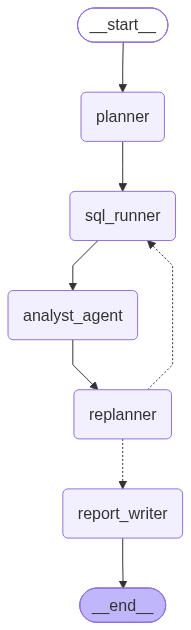

In [12]:
from IPython.display import Image, display

try:
    display(Image(rca_pipeline.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(Diagram render skipped -- {e}. See the Mermaid block above for the same graph.)")


## Running the pipeline end to end

Every query's real rows and the analyst's real finding are printed as they happen.


In [13]:
result = rca_pipeline.invoke({"question": ba_question})

print(f"Final plan (after any replanning): {result['plan']}")
print(f"Total steps executed: {len(result['findings'])}")
print(f"Worst region identified: {result.get('worst_region')}")
print(f"Worst product identified: {result.get('worst_product')}")


Final plan (after any replanning): ['revenue_by_week', 'revenue_by_region', 'revenue_by_product', 'check_stockout']
Total steps executed: 4
Worst region identified: West
Worst product identified: Widget Pro


In [14]:
print("=" * 70)
print("INVESTIGATION TRAIL (each step's real query result + finding)")
print("=" * 70)
for i, f in enumerate(result["findings"]):
    print(f"\n[{i}] step={f['step']}")
    print(f"    raw rows: {f['raw']}")
    print(f"    finding:  {f['summary']}")


INVESTIGATION TRAIL (each step's real query result + finding)

[0] step=revenue_by_week
    raw rows: [{'week': 'week1', 'total_revenue': 109225.0}, {'week': 'week2', 'total_revenue': 103100.0}]
    finding:  Total revenue decreased from $109,225 in week 1 to $103,100 in week 2, representing a decline of $6,125 or approximately 5.6%.

[1] step=revenue_by_region
    raw rows: [{'region': 'East', 'week': 'week1', 'total_revenue': 36385.0}, {'region': 'East', 'week': 'week2', 'total_revenue': 36395.0}, {'region': 'North', 'week': 'week1', 'total_revenue': 36230.0}, {'region': 'North', 'week': 'week2', 'total_revenue': 37010.0}, {'region': 'West', 'week': 'week1', 'total_revenue': 36610.0}, {'region': 'West', 'week': 'week2', 'total_revenue': 29695.0}]
    finding:  In comparing total revenue from week 1 to week 2, the East region saw a slight increase from $36,385 to $36,395, while the North region increased from $36,230 to $37,010. However, the West region experienced a significant decli

In [15]:
print("=" * 70)
print("ROOT-CAUSE REPORT")
print("=" * 70)
print(result["final_report"])


ROOT-CAUSE REPORT
**Root-Cause Analysis Report**

1. **Headline Number**: Total revenue decreased by $6,125 (approximately 5.6%) from $109,225 in week 1 to $103,100 in week 2.

2. **Region and Product Traced**: The decline is traced to the West region, particularly the 'Widget Pro' product.

3. **Specific Mechanism**: The data shows that significant stockouts occurred in week 2, particularly affecting 'Widget Pro', which saw a drastic revenue drop from $12,060 to $5,625. The stockouts on days 2 through 5 resulted in zero sales during those days, collapsing unit volume and leading to the overall revenue decline.

4. **Recommended Action**: Implement a more robust inventory management system to prevent stockouts, particularly for high-demand products like 'Widget Pro', ensuring consistent product availability and minimizing revenue loss.


**Expected output**: `revenue_by_week` should show a real week1->week2 total revenue
decline; `revenue_by_region` should identify `West` as the worst-declining region;
`revenue_by_product` (scoped to `West`) should identify `Widget Pro` as the
worst-declining product **and** show its unit volume collapsing, not just its revenue --
which is the signal that should trigger the replanner to insert `check_stockout` (a step
that was never in the planner's original output). `check_stockout` should then show
several `week2` days with `stockout=1` and near-zero `units_sold` for `West` / `Widget
Pro`, and the final report should name the stockout as the actual mechanism, not just
"West underperformed."

## Common mistakes

- **Hardcoding the drill-down target instead of reading it from the data.**
  `sql_runner_node`'s `revenue_by_product` step uses `state["worst_region"]`, which was
  set by `analyst_agent_node` from the *actual* query result, not a fixed string --
  swap in a hardcoded `"West"` and the investigation stops being a real discovery
  process and becomes a scripted demo.
- **Triggering `check_stockout` on revenue decline alone.** The replanner's system
  message specifically ties the insertion to a *unit volume* collapse, not just a
  revenue decline -- a product could show lower revenue purely from a price change or
  soft demand, which would call for a different next step (or none), not a stockout
  check. Reacting to the wrong signal would insert an irrelevant step.
- **Letting the analyst agent make the routing decision.** `analyst_agent_node` only
  ever reports facts (and, structurally, the worst region/product as a typed field) --
  it never decides whether to drill down further. That decision is `replanner_node`'s
  alone, keeping "what does this data show" and "what should happen next" as separate
  concerns.
- **Trusting an optional structured-output field unconditionally.** This notebook's own
  build hit exactly this: `AnalystFinding.worst_product` is an `Optional[str]` the LLM
  is supposed to fill in, and on at least one real run it came back empty even though
  the underlying data clearly showed a worst product -- which crashed `sql_runner_node`
  with a `KeyError` the first time this notebook was run, before the deterministic
  fallback (computing worst_region/worst_product directly from the real rows when the
  LLM misses) was added. An optional structured-output field the rest of the pipeline
  depends on needs a real fallback, not just an `Optional[...]` type hint and hope.
- **Confusing this with the fixed 4-stage sequential pipeline in
  `03_sequential_pipeline.ipynb`.** That notebook's stages are always the same fixed
  order regardless of what any stage finds. Here, the very identity of the *later* steps
  (`check_stockout`, and which region/product it targets) is only knowable after earlier
  steps' real results come in.

## Explain like I'm 12

Imagine you're a detective trying to figure out why the class bake sale made less money
this week than last week. You don't write down every possible question you could ever
ask before you start -- that would take forever and most of it wouldn't matter. Instead:
first you check *did* we actually make less money (yes). Then you check *which table*
made less (the cookie table). Then you check *which cookie* sold worse at that table
(chocolate chip). At that point, a good detective doesn't stop and guess -- they notice
something specific and weird (almost none sold on four particular days) and *that's*
what makes them ask one more, very targeted question that nobody would have thought to
ask at the very beginning: "were we even out of chocolate chip cookies those days?" And
yes -- you were. That last question only existed because of what the third question
found.

## Explain for interview

"This is planner-executor-replan applied to root-cause analysis: a planner drafts a
broad-to-narrow drill-down plan from the question alone, each step executes a real SQL
query, an analyst agent summarizes one result set (and, as a structured field, names the
worst-performing region/product for the next query to target), and a replanner --
seeing only that summary -- decides whether the plan needs a new, previously unplanned
step. The `check_stockout` step here only gets inserted because `revenue_by_product`'s
real result showed a unit-volume collapse, not just a revenue dip -- the specific signal
that distinguishes a supply problem from a demand or pricing one. This is the pattern's
strongest use case: an investigation where the next useful query is fundamentally
unknowable until the previous one's real result comes back."

## Glossary

- **Drill-down step** -- one query in the investigation, narrower in scope than the
  step before it (week -> region -> product -> stockout check).
- **Worst region / worst product** -- structured fields the `analyst_agent` extracts
  directly from real query results, used to parameterize the next query instead of a
  hardcoded target.
- **Root cause** -- the specific, data-supported mechanism (a stockout) behind an
  observed metric change, as opposed to just naming where the change occurred.
- **Replan trigger** -- here, a unit-volume collapse (not just a revenue decline)
  within the already-identified worst region/product, the signal that distinguishes a
  supply-side problem worth a stockout check from an ordinary demand/price fluctuation.

## Checkpoint questions

1. **Q: Why can't the planner include `check_stockout` in its initial plan?**
   A: The planner only sees the BA question, before any query has run -- it has no way
   to know yet whether a stockout is even relevant, or which region/product it might
   apply to; that only becomes knowable once `revenue_by_product`'s real result comes
   back.

2. **Q: What specific signal in `revenue_by_product`'s finding should cause the
   replanner to insert `check_stockout`, versus not?**
   A: A collapse in unit volume (not just revenue) for the worst-performing
   region/product -- a supply-side signature. A revenue decline driven by price or
   ordinary demand softness, without a unit-volume collapse, should not trigger it.

3. **Q: Why does `sql_runner_node` read `state["worst_region"]` instead of a hardcoded
   region name?**
   A: So the investigation's drill-down target is genuinely determined by real data
   from an earlier step, not scripted in advance -- the same discovery process would
   correctly point somewhere else if the underlying data were different.

4. **Q: What's the difference between this notebook's plan mutation and the trip
   notebook's?**
   A: Structurally identical (a replanner inserts a step in reaction to a specific
   finding) -- the domains differ (SQL drill-down vs. travel research) but the pattern,
   agent roles, and the "insertion is caused by a concrete observed finding, not
   speculation" rule are the same.
